In [1]:
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from synthesizer.grid import Grid
from synthpop.galaxy_population import GalaxyPopulation
from synthpop.model import Model, Default
from unyt import yr, Myr, Msun, Gyr, unyt_quantity, Mpc, dimensionless


In [2]:
# load grid
grid = Grid("test_grid")

# load default model
model = Default()

# Define the volume of the galaxy population
volume = 1E4 * Mpc**3

In [3]:


# Instantiate the galaxy population
galpop = GalaxyPopulation(
    minimum_stellar_mass=1E9*Msun, 
    maximum_stellar_mass=1E11*Msun, 
    volume=volume,
    model=model,
    grid=grid,
    cosmology=cosmo,
    redshift=0.0,
    random_seed=42)

print(galpop)




/Users/sw376/Dropbox/Research/projects/synthpop/venv/lib/python3.10/site-packages/unyt/array.py:1900: RuntimeWarning: divide by zero encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


----------
SUMMARY OF GALAXY POPULATION
Number of galaxies: 342
Volume: 1.00e+04 Mpc**3
Redshift: 0.0
Total surviving stellar mass density: 2.56e+08 Msun/Mpc**3
Range of surviving stellar masses: 1.01e+09 - 8.72e+10
Age of the universe at z=0.0: 1.38e+04 Myr
----------



/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_population.py:277: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


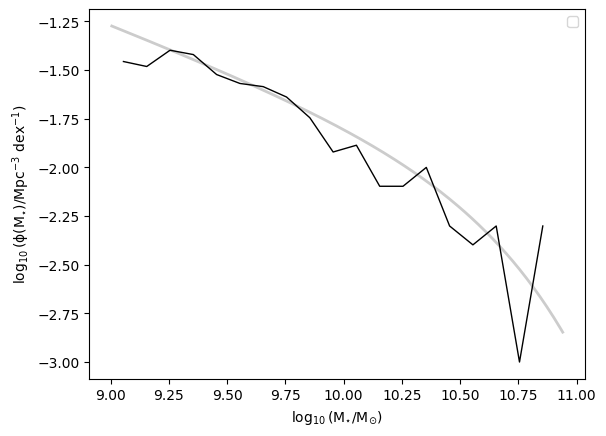

In [4]:


galpop.plot_stellar_mass_function()




/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_population.py:300: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(bin_centres), np.log10(phi_sampled), c='k', alpha=1, lw=1)
/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_population.py:304: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


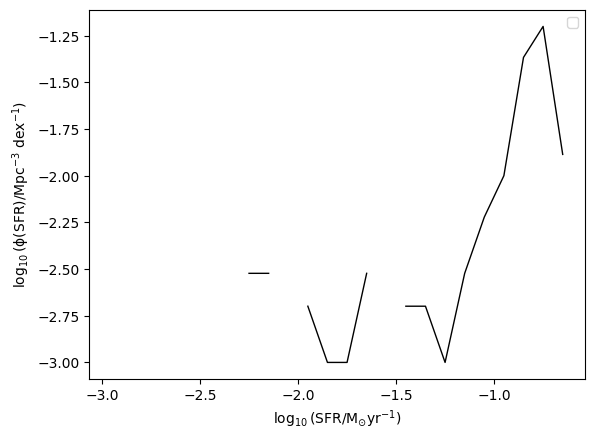

In [5]:

galpop.plot_star_formation_rate_distribution_function()



/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_population.py:349: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


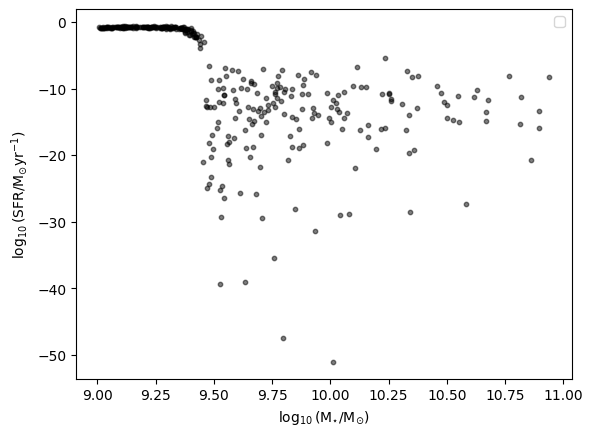

/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_population.py:365: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


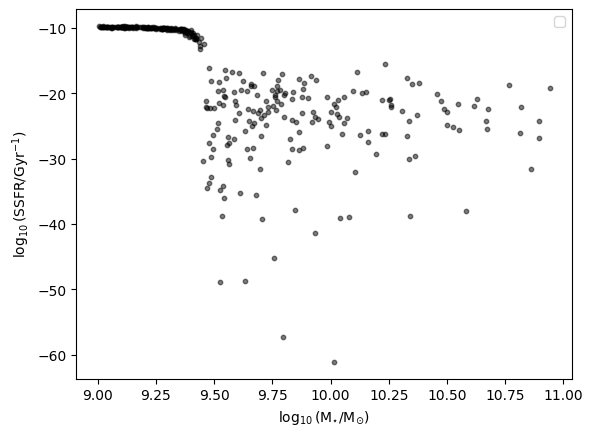

In [6]:
galpop.plot_sfr_vs_stellar_mass()
galpop.plot_ssfr_vs_stellar_mass()

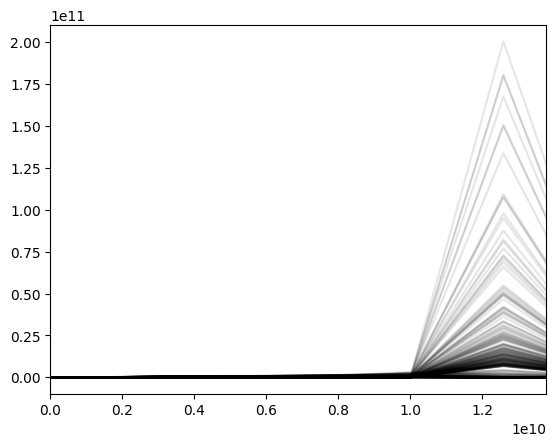

In [7]:
galpop.plot_sfhs(N='all')

|====== EmissionModel: incident ======|
|-------------------------------------|
|  INCIDENT (stellar)                 |
|-------------------------------------|
|Extraction model:                    |
|  Grid: test_grid                    |
|  Extract key: incident              |
|  Use velocity shift: False          |
|  Save emission: True                |
|=====================================|
Plotting spectra for 10 out of 342 galaxies in the population.


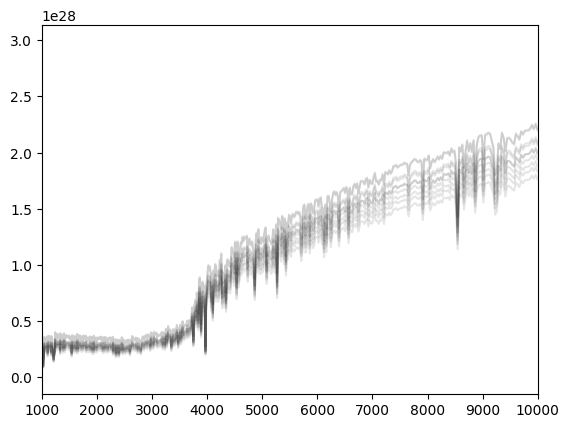

In [8]:
from synthesizer.emission_models import IncidentEmission

incident = IncidentEmission(grid=grid)
print(incident)


galpop.generate_spectra(incident)

galpop.plot_spectra('incident')


/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_population.py:332: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


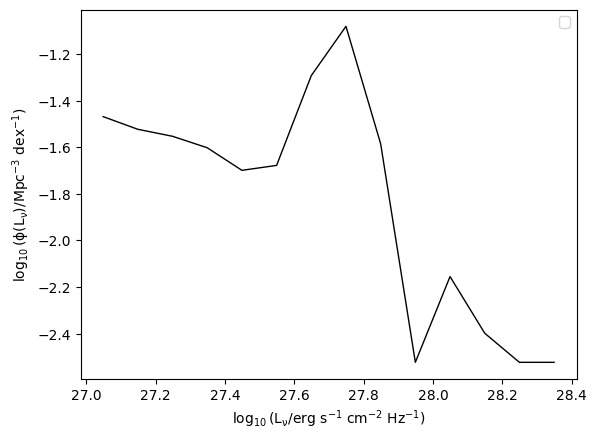

In [9]:

from synthesizer.filters import UVJ

# Get a UVJ filter collection
uvj = UVJ(new_lam=grid.lam)


galpop.generate_photometry('incident', uvj)


galpop.plot_luminosity_function('incident', 'U')

/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_population.py:383: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


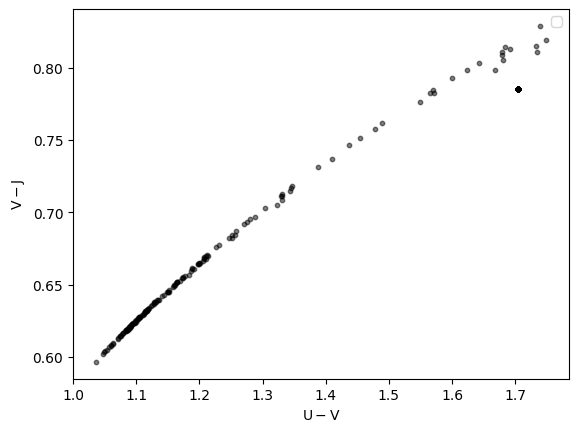

In [10]:
galpop.plot_color_color_diagram('incident', ['U','V', 'J'])

## Project galaxy population to earlier time

In [11]:
galpop_z1 = galpop.project_to_earlier_epoch(redshift=3.0)

print(galpop)
print(galpop_z1)

11643.13146468227 Myr
----------
SUMMARY OF GALAXY POPULATION
Number of galaxies: 342
Volume: 1.00e+04 Mpc**3
Redshift: 0.0
Total surviving stellar mass density: 2.56e+08 Msun/Mpc**3
Range of surviving stellar masses: 1.01e+09 - 8.72e+10
Age of the universe at z=0.0: 1.38e+04 Myr
----------

----------
SUMMARY OF GALAXY POPULATION
Number of galaxies: 342
Volume: 1.00e+04 Mpc**3
Redshift: 3.0
Total surviving stellar mass density: 1.96e+08 Msun/Mpc**3
Range of surviving stellar masses: 9.79e+02 - 7.45e+10
Age of the universe at z=3.0: 2.14e+03 Myr
----------



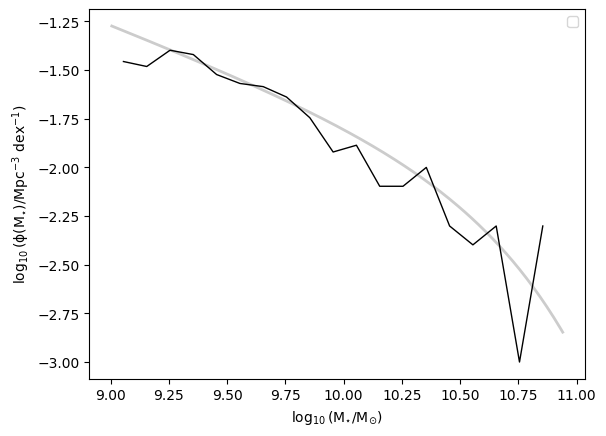

/Users/sw376/Dropbox/Research/projects/synthpop/src/synthpop/galaxy_population.py:273: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(bin_centres), np.log10(phi_sampled), c='k', alpha=1, lw=1)


13786.885302009709 Myr


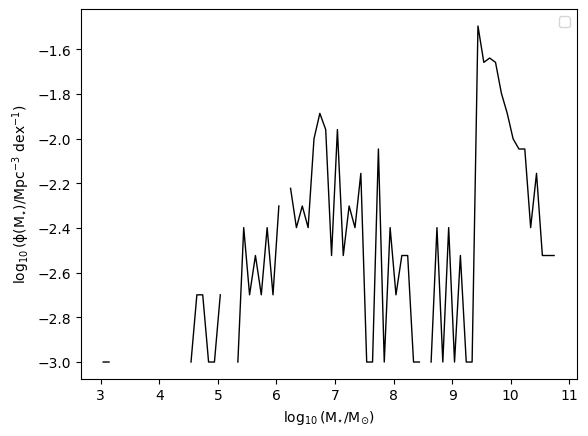

2143.7538373274374 Myr


In [12]:

galpop.plot_stellar_mass_function()
print(galpop.age_of_the_universe)
galpop_z1.plot_stellar_mass_function()
print(galpop_z1.age_of_the_universe)
